In [86]:
# IMPORTATION DES LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')



In [87]:
# CHARGEMENT DU DATASET

wine = load_wine()

X = wine.data
y = wine.target

columns = wine.feature_names


In [88]:
# Création DataFrame

df = pd.DataFrame(X, columns=columns)

df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [89]:
# INFORMATIONS GENERALES

print("\nShape du dataset :")
df.shape

print("\nInformations générales :")
df.info()

print("\nValeurs manquantes :")
df.isnull().sum()



Shape du dataset :

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline           

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [90]:
# STATISTIQUES DESCRIPTIVES

print("\nStatistiques descriptives :")
df.describe()



Statistiques descriptives :


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


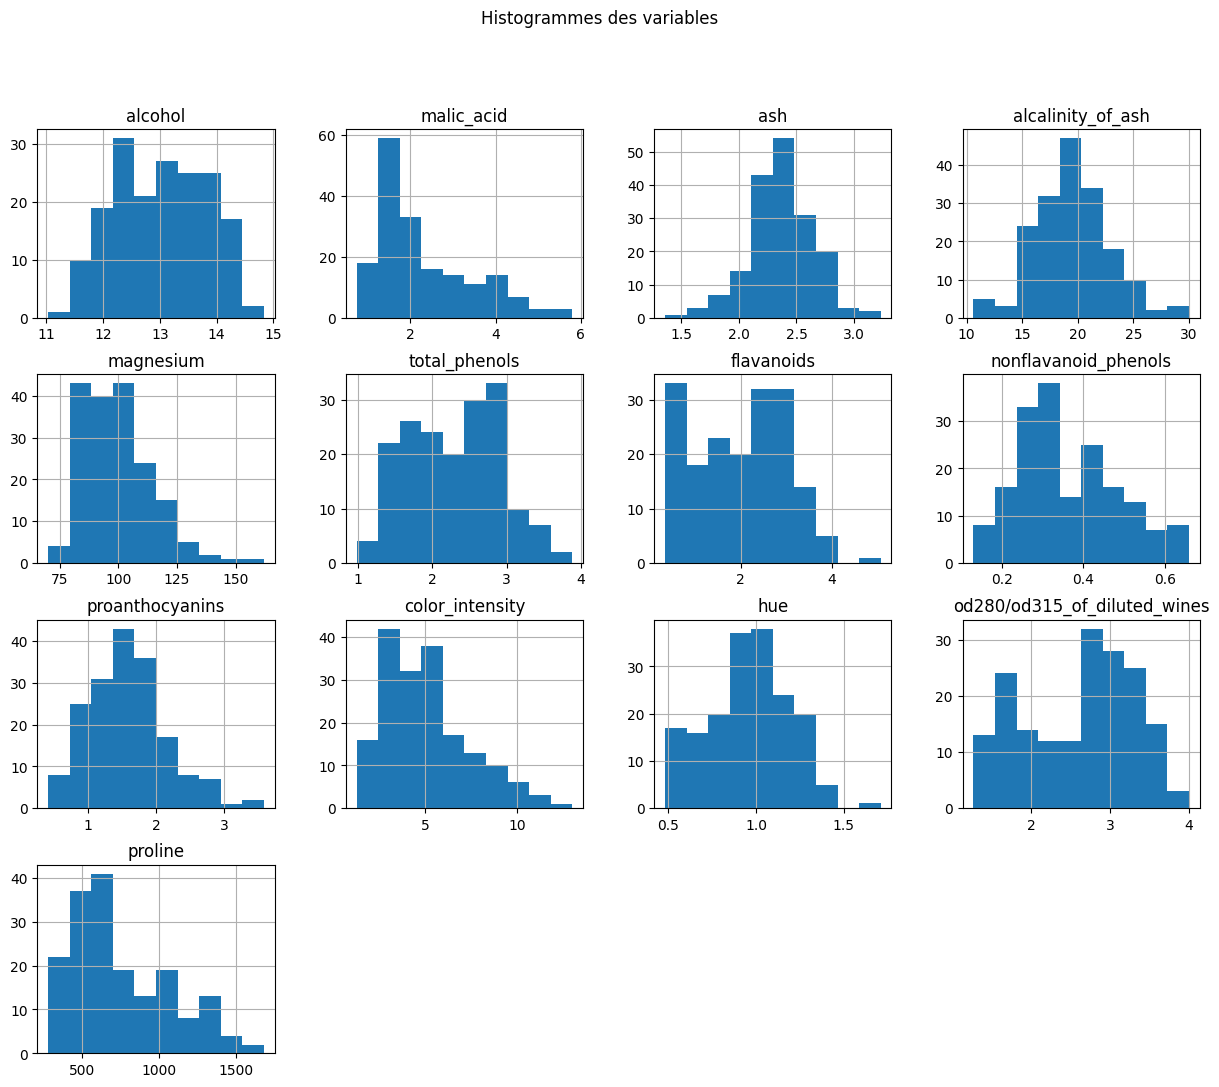

In [91]:
# HISTOGRAMMES

df.hist(figsize=(15,12))
plt.suptitle("Histogrammes des variables")
plt.show()


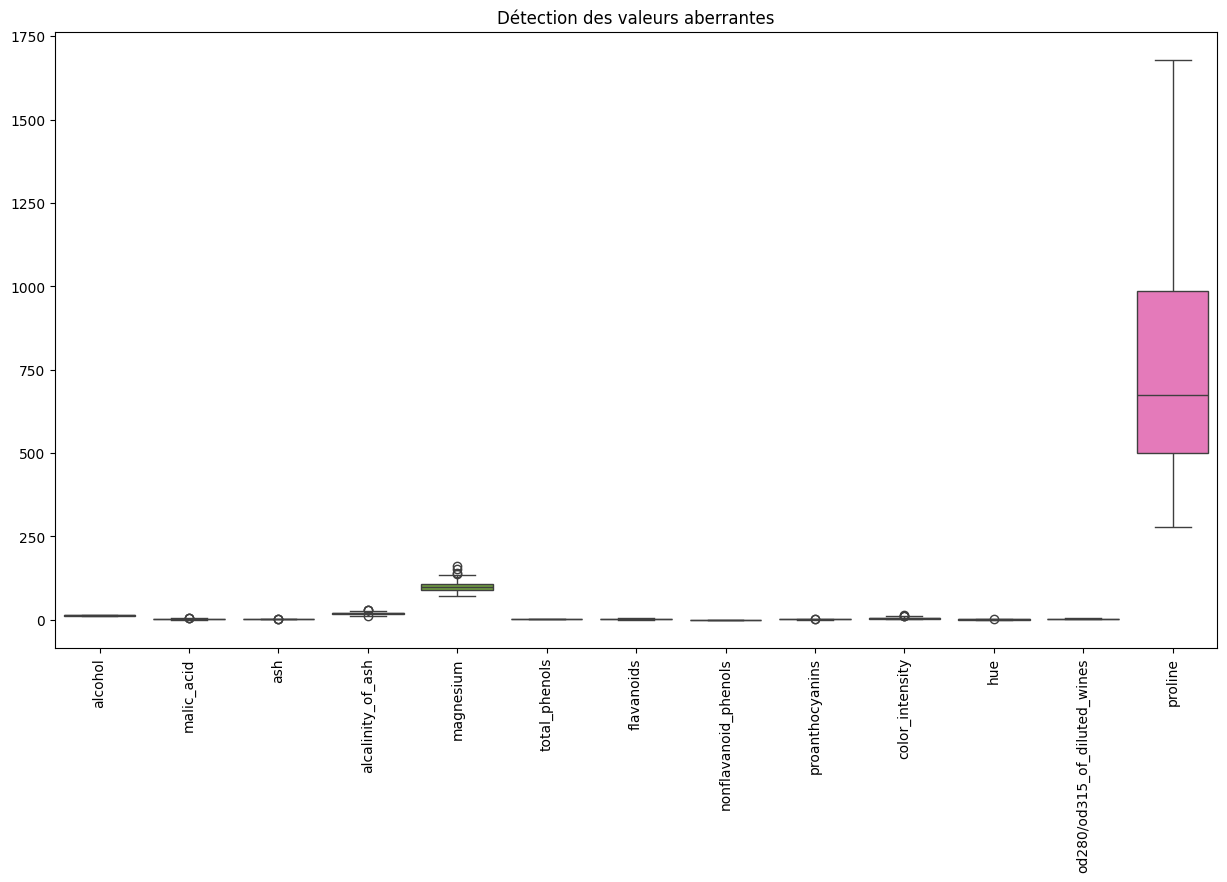

In [92]:
# BOXPLOTS

plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Détection des valeurs aberrantes")
plt.show()


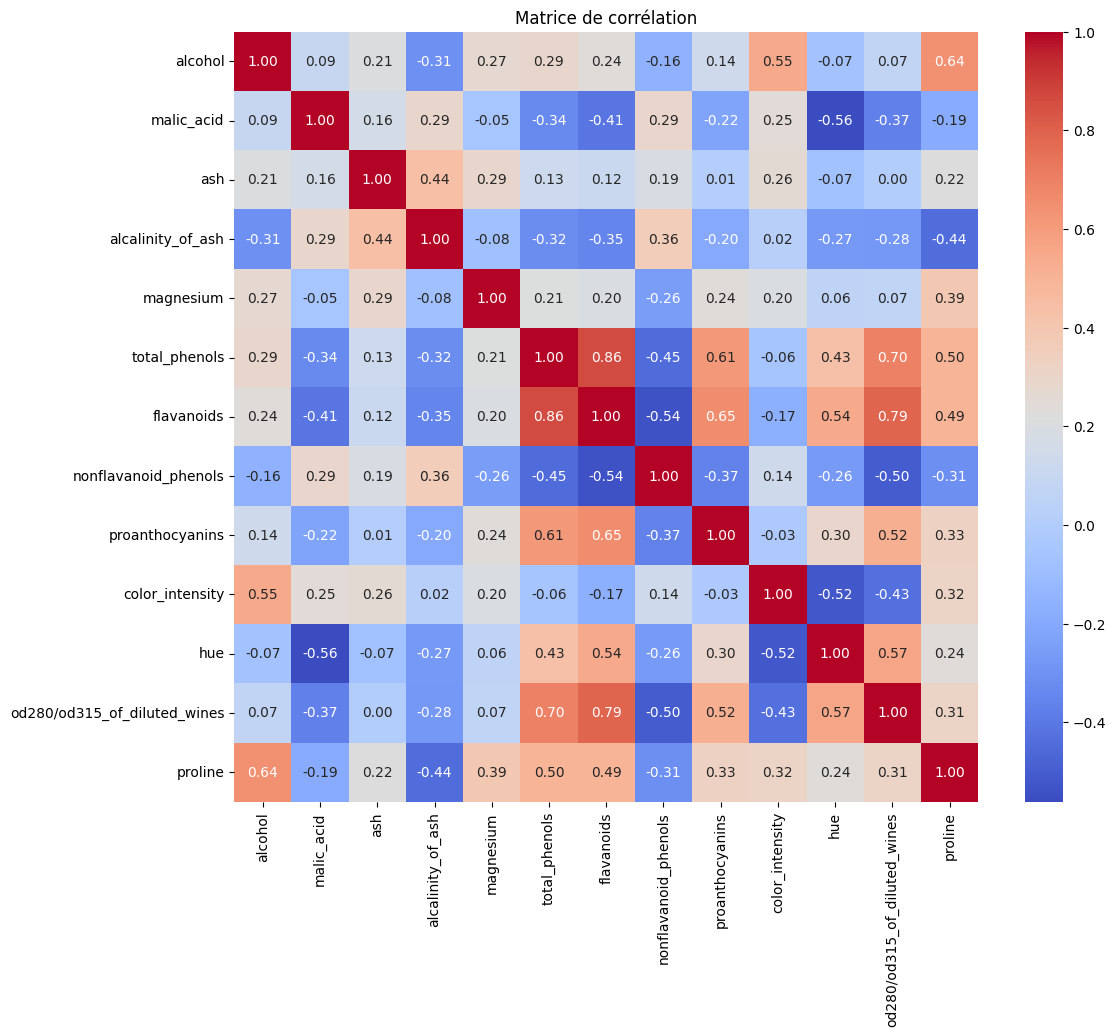

In [93]:
# MATRICE DE CORRELATION

plt.figure(figsize=(12,10))
correlation = df.corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Matrice de corrélation")
plt.savefig("figure8.png")
plt.show()


In [94]:
# NORMALISATION DES DONNEES

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


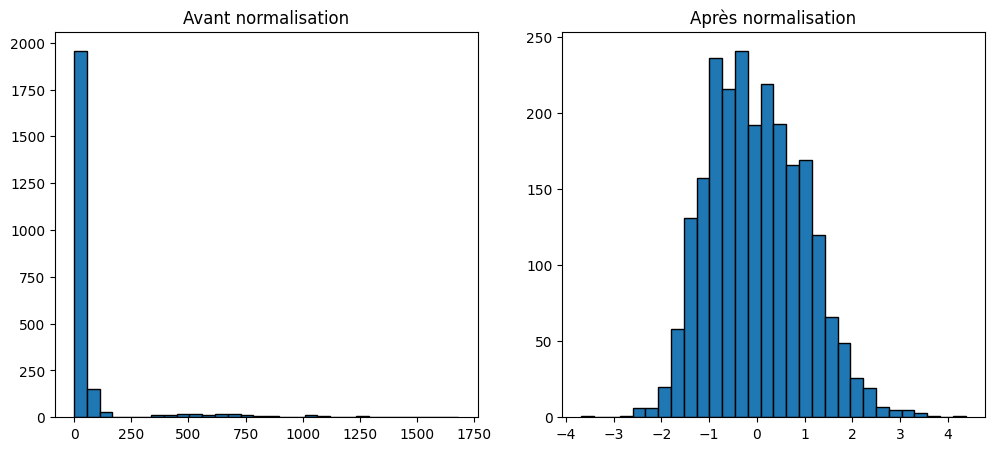

In [95]:
# Comparaison avant / après (Histogrammes)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(X.flatten(), bins=30, edgecolor='black')
plt.title("Avant normalisation")

plt.subplot(1,2,2)
plt.hist(X_scaled.flatten(), bins=30, edgecolor='black')
plt.title("Après normalisation")
plt.show()


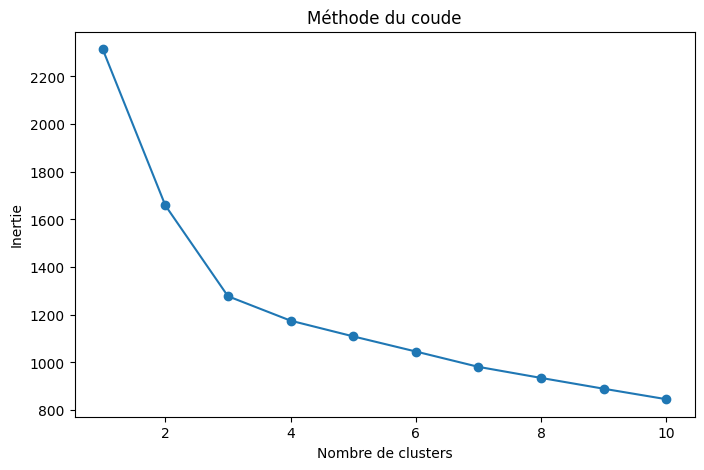

In [96]:
# ELBOW METHOD

inertias = []
K_range = range(1,11)

for k in K_range:
    model = KMeans(n_clusters=k,
                   random_state=42,                   n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.show()


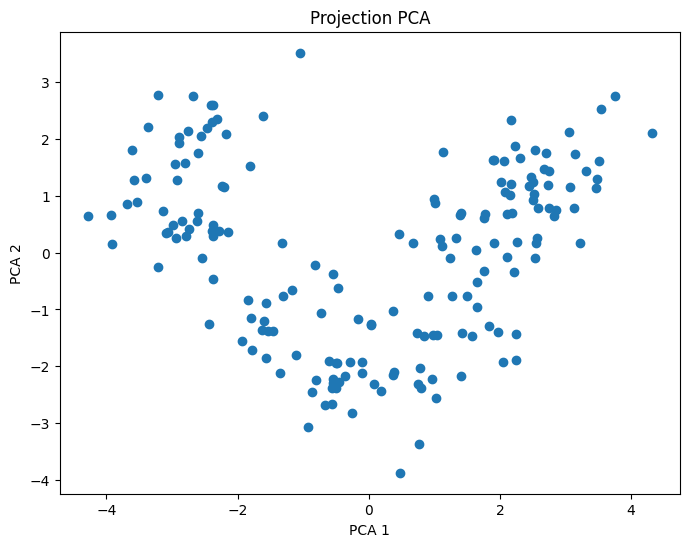

In [97]:
# PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],
            X_pca[:,1])

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Projection PCA")
plt.show()


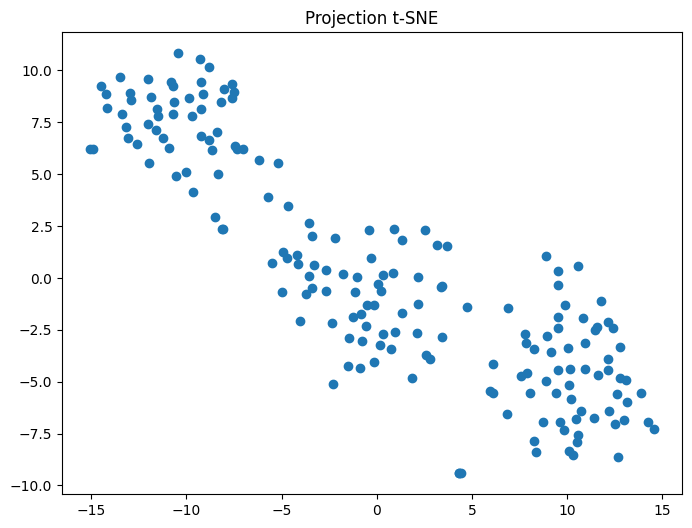

In [98]:
# t-SNE

tsne = TSNE(n_components=2,
            random_state=42,
            perplexity=30)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0],
            X_tsne[:,1])

plt.title("Projection t-SNE")
plt.show()


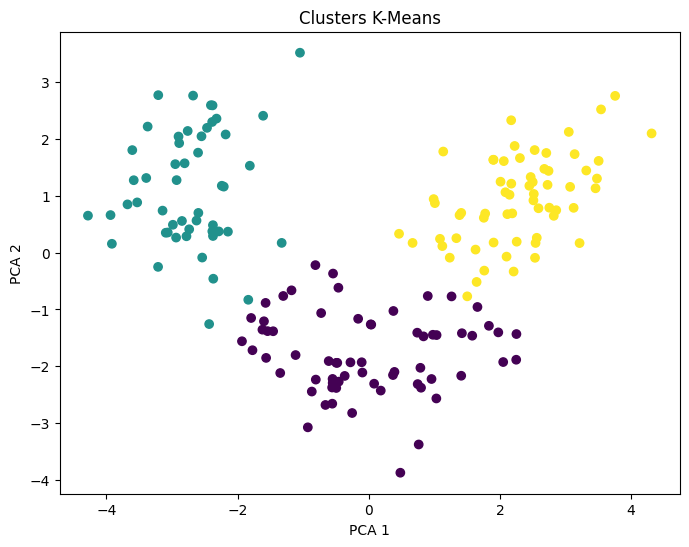

In [99]:
# K-MEANS

kmeans = KMeans(n_clusters=3,
                random_state=42,
                n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Visualisation PCA

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=kmeans_labels,
            cmap='viridis')

plt.title("Clusters K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()



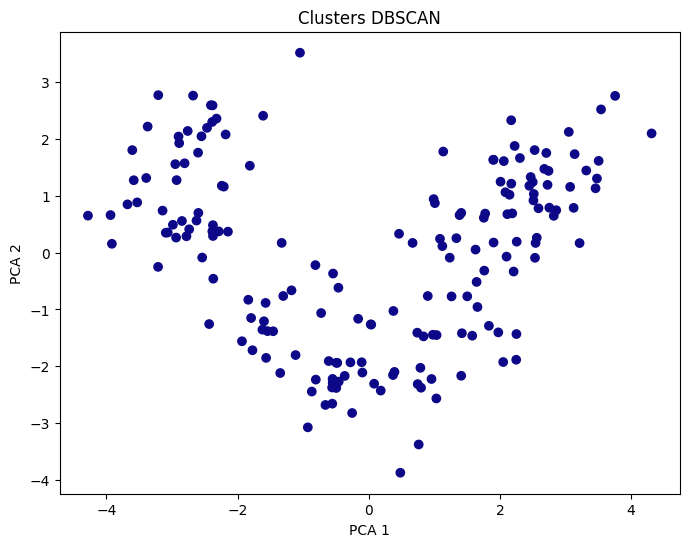

In [100]:
# DBSCAN

dbscan = DBSCAN(eps=1.5,
                min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=dbscan_labels,
            cmap='plasma')

plt.title("Clusters DBSCAN")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


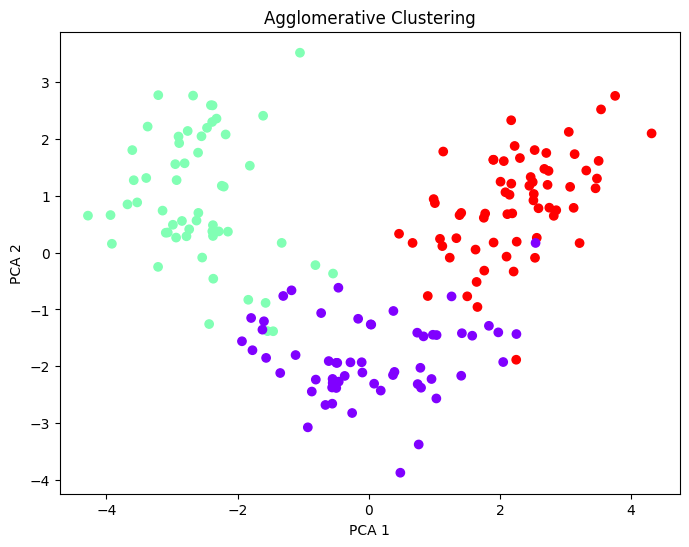

In [101]:
# AGGLOMERATIVE CLUSTERING

agg = AgglomerativeClustering(n_clusters=3)

agg_labels = agg.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=agg_labels,
            cmap='rainbow')

plt.title("Agglomerative Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


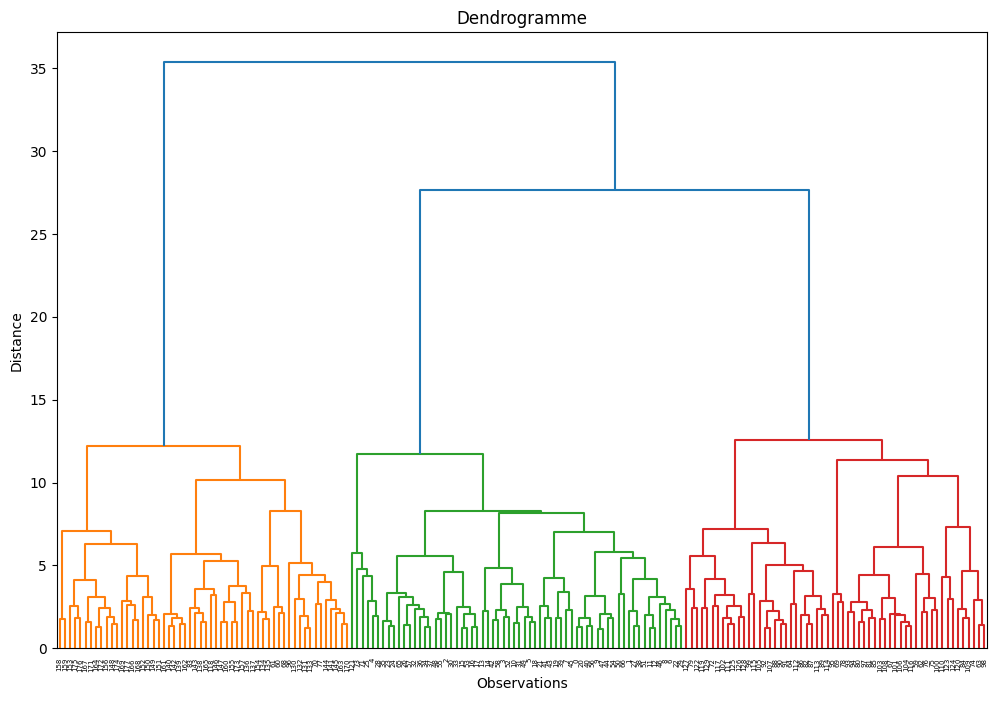

In [102]:
# DENDROGRAMME

linked = linkage(X_scaled,
                 method='ward')

plt.figure(figsize=(12,8))
dendrogram(linked)
plt.title("Dendrogramme")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()


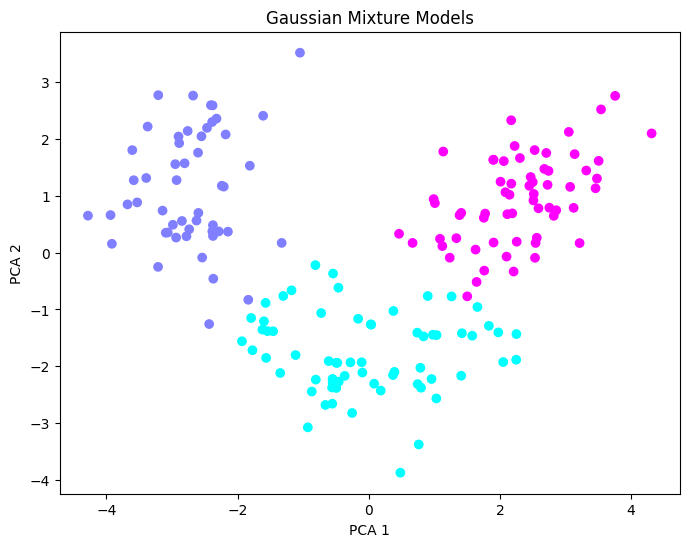

In [103]:
# GMM

gmm = GaussianMixture(n_components=3,
                      random_state=42)

gmm.fit(X_scaled)

gmm_labels = gmm.predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=gmm_labels,
            cmap='cool')
plt.title("Gaussian Mixture Models")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()



In [104]:
# EVALUATION DES MODELES

results = []

# ---------- KMEANS ----------

results.append([
    "K-Means",
    silhouette_score(X_scaled, kmeans_labels),
    davies_bouldin_score(X_scaled, kmeans_labels),
    calinski_harabasz_score(X_scaled, kmeans_labels)
])

# ---------- AGGLOMERATIVE ----------

results.append([
    "Agglomerative",
    silhouette_score(X_scaled, agg_labels),
    davies_bouldin_score(X_scaled, agg_labels),
    calinski_harabasz_score(X_scaled, agg_labels)
])

# ---------- GMM ----------

results.append([
    "GMM",
    silhouette_score(X_scaled, gmm_labels),
    davies_bouldin_score(X_scaled, gmm_labels),
    calinski_harabasz_score(X_scaled, gmm_labels)
])

# ---------- DBSCAN ----------

if len(set(dbscan_labels)) > 1:

    results.append([
        "DBSCAN",
        silhouette_score(X_scaled, dbscan_labels),
        davies_bouldin_score(X_scaled, dbscan_labels),
        calinski_harabasz_score(X_scaled, dbscan_labels)
    ])


In [105]:
# TABLEAU DES RESULTATS

results_df = pd.DataFrame(results,
                          columns=[
                              "Algorithme",
                              "Silhouette",
                              "Davies-Bouldin",
                              "Calinski-Harabasz"
                          ])

print("\nRésultats des modèles :")
results_df



Résultats des modèles :


,Algorithme,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.284859,1.389188,70.940008
1,Agglomerative,0.277444,1.418592,67.647468
2,GMM,0.284859,1.389188,70.940008


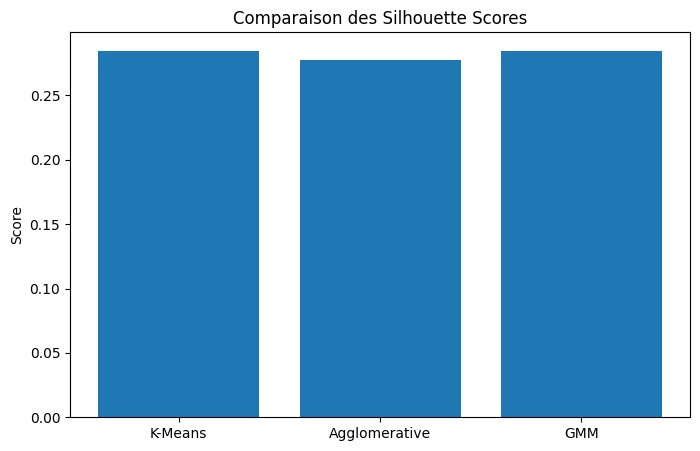

In [106]:
# GRAPHE SILHOUETTE

plt.figure(figsize=(8,5))

plt.bar(results_df["Algorithme"],
        results_df["Silhouette"])

plt.title("Comparaison des Silhouette Scores")
plt.ylabel("Score")
plt.show()


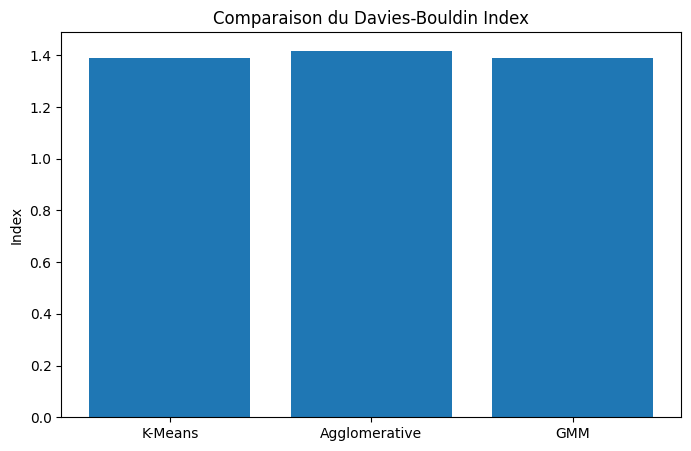

In [107]:
# GRAPHE DAVIES-BOULDIN

plt.figure(figsize=(8,5))

plt.bar(results_df["Algorithme"],
        results_df["Davies-Bouldin"])

plt.title("Comparaison du Davies-Bouldin Index")
plt.ylabel("Index")
plt.show()


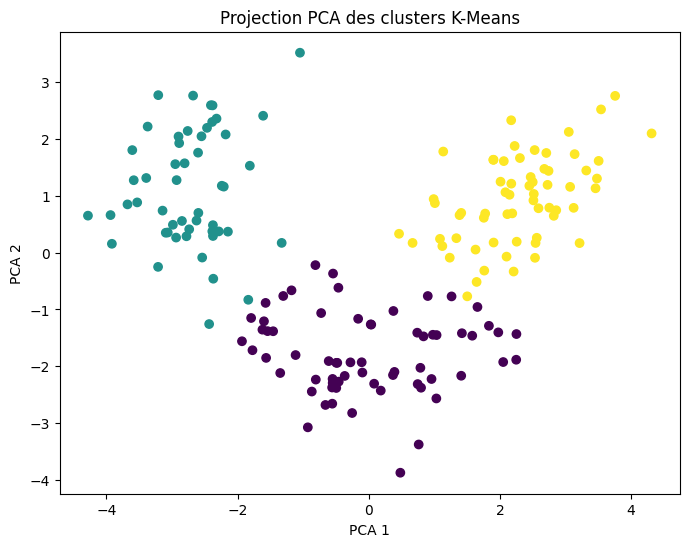

In [108]:
# PCA + KMEANS

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=kmeans_labels,
            cmap='viridis')

plt.title("Projection PCA des clusters K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


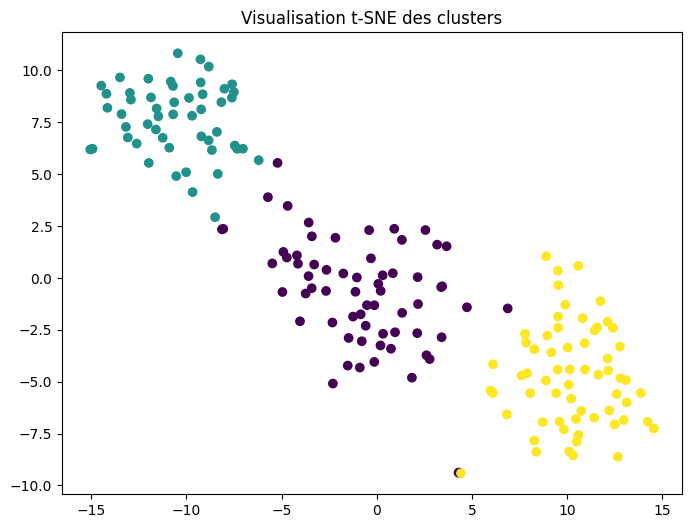

In [109]:
# t-SNE + CLUSTERS

plt.figure(figsize=(8,6))

plt.scatter(X_tsne[:,0],
            X_tsne[:,1],
            c=kmeans_labels,
            cmap='viridis')

plt.title("Visualisation t-SNE des clusters")
plt.show()
